# Gate B0/B1 — T1 baselines и frozen candidate

## tl;dr

На 911 train- и 130 validation-origins проверены пять предобъявленных моделей в 24 контролируемых фолдах. По составному development-score победил `B1_persistence_last_rate`: temporal validation MAE **7.311 мм/год**. После фиксации candidate record T1 test был открыт один раз: 175 origins, MAE **10.135 мм/год**, RMSE **19.878 мм/год**, bias **−5.165 мм/год**. Независимая проверка 93 расчётов и хэшей прошла без ошибок.

Это stage-candidate Gate B0/B1, а не финальная модель диплома. Test-результат терминален для этого кандидата и не должен использоваться для изменения его параметров.

## Context & Methods

Цель — сравнить persistence, profile-aware robust trend, fixed Kalman, Ridge и ExtraTrees для `observed_rate_mm_y`, не открывая test до заморозки одного кандидата.

Использованы только frozen manifests `t1_v1` и executable allowlist. Headline metric — обычный MAE; precision-weighted метрики вторичны, а веса пересчитываются из `sigma_rate_mm_y` внутри каждого train scope. Candidate score — взвешенная сумма MAE, нормированных на B1: 50% temporal holdout, 20% rolling-origin, 20% leave-profile-out, 10% leave-zone-out, плюс заранее заданный complexity penalty.

### Key Assumptions

- 2024 validation не является IID-выборкой: 130 origins относятся к 90 повторяющимся траекториям.
- Leave-profile/zone-out выполнены в forward-only режиме: fit использует только pre-2024 labels.
- Point/profile IDs не попадают в estimator matrix; `point_id` используется fixed Kalman только как ключ локального причинного состояния.
- Notebook читает уже замороженные test outputs и не вызывает model-facing test loader повторно.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    if root.parent == root:
        raise RuntimeError('Repository root not found')
    root = root.parent

artifact_dir = root / 'artifacts' / 'model_selection' / 't1_b0_b1_v1'
candidate = json.loads((root / 'artifacts' / 'model_selection' / 'frozen_candidate.json').read_text(encoding='utf-8'))
development_report = json.loads((artifact_dir / 'development_report.json').read_text(encoding='utf-8'))
validation_report = json.loads((artifact_dir / 'validation_report.json').read_text(encoding='utf-8'))
ledger = json.loads((artifact_dir / 'test_access_ledger.json').read_text(encoding='utf-8'))
aggregate = pd.read_csv(artifact_dir / 'aggregate_metrics.csv')
ranking = pd.read_csv(artifact_dir / 'candidate_ranking.csv')
folds = pd.read_csv(artifact_dir / 'fold_contracts.csv')
development_predictions = pd.read_csv(artifact_dir / 'development_predictions.csv')
test_predictions = pd.read_csv(artifact_dir / 'test_predictions.csv')
test_metrics = pd.read_csv(artifact_dir / 'test_metrics.csv')

pd.set_option('display.max_columns', 30)
{
    'candidate_id': candidate['candidate_id'],
    'selected_model': candidate['selected_model'],
    'test_access_status': ledger['status'],
    'test_access_count': 1,
    'independent_checks': validation_report['summary'],
}

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\SUKUNA-AI\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


{'candidate_id': 't1-b0b1-v1-3bfcff231705',
 'selected_model': 'B1_persistence_last_rate',
 'test_access_status': 'consumed',
 'test_access_count': 1,
 'independent_checks': {'checks': 93, 'failed': 0}}

## Data

In [2]:
pd.DataFrame([
    {
        'split': 'train',
        'rows': development_report['data']['train_rows'],
        'sample_ids_sha256': development_report['data']['train_sample_ids_sha256'],
    },
    {
        'split': 'validation',
        'rows': development_report['data']['validation_rows'],
        'sample_ids_sha256': development_report['data']['validation_sample_ids_sha256'],
    },
    {
        'split': 'test (opened once after freeze)',
        'rows': ledger['test_rows'],
        'sample_ids_sha256': ledger['test_sample_ids_sha256'],
    },
])

,split,rows,sample_ids_sha256
0,train,911,2cd9ef9d27536d6d4e63ef0a56ad51002823d1306ff7c3...
1,validation,130,f72ce0a50c16bccca3ca87df4f4a7465b4d9eca2933e0d...
2,test (opened once after freeze),175,8d0db55dba8db96297c6b816e65e2601fdc4bbc014a81b...


In [3]:
folds.groupby('design').agg(
    folds=('fold_id', 'nunique'),
    min_train_rows=('train_rows', 'min'),
    max_train_rows=('train_rows', 'max'),
    min_validation_rows=('validation_rows', 'min'),
    max_validation_rows=('validation_rows', 'max'),
)

,folds,min_train_rows,max_train_rows,min_validation_rows,max_validation_rows
design,,,,,
leave_profile_out,14,824,867,4,21
leave_zone_out,4,489,829,8,74
rolling_origin,5,823,1027,14,88
temporal_holdout,1,911,911,130,130


In [4]:
assert (pd.to_datetime(folds['train_target_date_max']) < pd.to_datetime(folds['validation_target_date_min'])).all()
assert development_predictions['y_pred'].notna().all()
assert pd.to_datetime(development_predictions['target_date']).max() < pd.Timestamp('2025-01-01')
print('Forward-only fold order and development-only dates: OK')

Forward-only fold order and development-only dates: OK


## Results

In [5]:
ranking[[
    'rank', 'model_id', 'selection_score',
    'temporal_holdout_mae', 'rolling_origin_mae',
    'leave_profile_out_mae', 'leave_zone_out_mae', 'selected'
]]

,rank,model_id,selection_score,temporal_holdout_mae,rolling_origin_mae,leave_profile_out_mae,leave_zone_out_mae,selected
0,1,B1_persistence_last_rate,1.000000,7.310922,6.823794,7.310922,7.310922,True
1,2,B5_fixed_kalman,1.107918,8.036036,7.696274,8.036036,8.036036,False
2,3,M2_extra_trees,1.184091,7.527837,6.764586,8.681270,16.340147,False
3,4,M1_ridge,1.206631,8.133646,7.506193,9.660393,11.777233,False
4,5,B3_profile_robust_trend,1.426572,10.414165,9.635944,10.443626,10.543586,False


In [6]:
mae_table = aggregate.pivot(index='model_id', columns='design', values='mae')
mae_table = mae_table.loc[ranking.sort_values('rank')['model_id']]
mae_table.round(3)

design,leave_profile_out,leave_zone_out,rolling_origin,temporal_holdout
model_id,,,,
B1_persistence_last_rate,7.311,7.311,6.824,7.311
B5_fixed_kalman,8.036,8.036,7.696,8.036
M2_extra_trees,8.681,16.340,6.765,7.528
M1_ridge,9.660,11.777,7.506,8.134
B3_profile_robust_trend,10.444,10.544,9.636,10.414


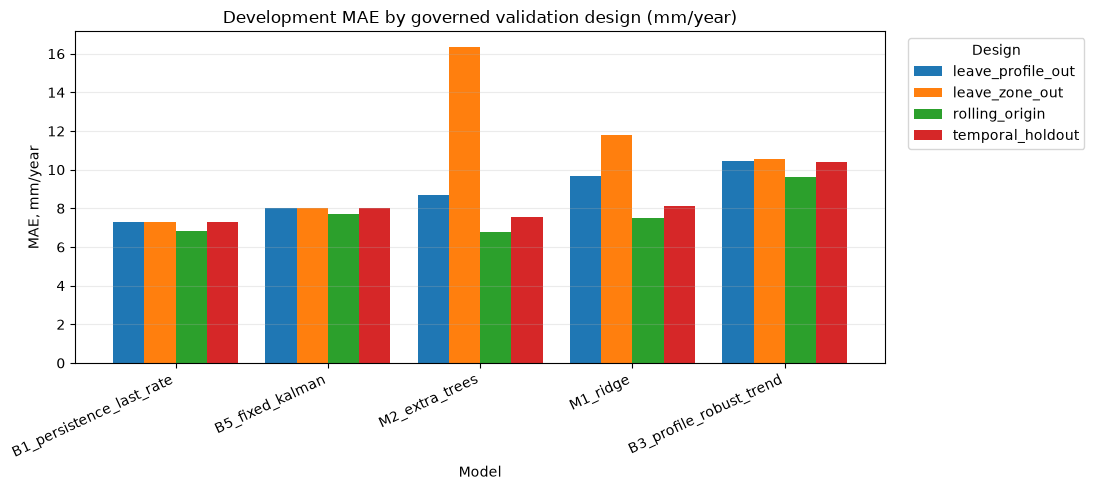

In [7]:
ax = mae_table.plot(kind='bar', figsize=(11, 5), width=0.82)
ax.set_title('Development MAE by governed validation design (mm/year)')
ax.set_ylabel('MAE, mm/year')
ax.set_xlabel('Model')
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Design', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### Frozen candidate and one-time test

In [8]:
validation_row = aggregate.loc[
    aggregate['design'].eq('temporal_holdout')
    & aggregate['model_id'].eq(candidate['selected_model'])
].iloc[0]
test_row = test_metrics.iloc[0]
comparison = pd.DataFrame([
    {'split': 'validation', **validation_row[['n', 'mae', 'rmse', 'bias', 'r2']].to_dict()},
    {'split': 'test', **test_row[['n', 'mae', 'rmse', 'bias', 'r2']].to_dict()},
])
comparison['mae_change_vs_validation_percent'] = [
    0.0,
    100.0 * (test_row['mae'] - validation_row['mae']) / validation_row['mae'],
]
comparison.round(3)

,split,n,mae,rmse,bias,r2,mae_change_vs_validation_percent
0,validation,130,7.311,11.071,-3.046,0.942,0.000
1,test,175,10.135,19.878,-5.165,0.848,38.625


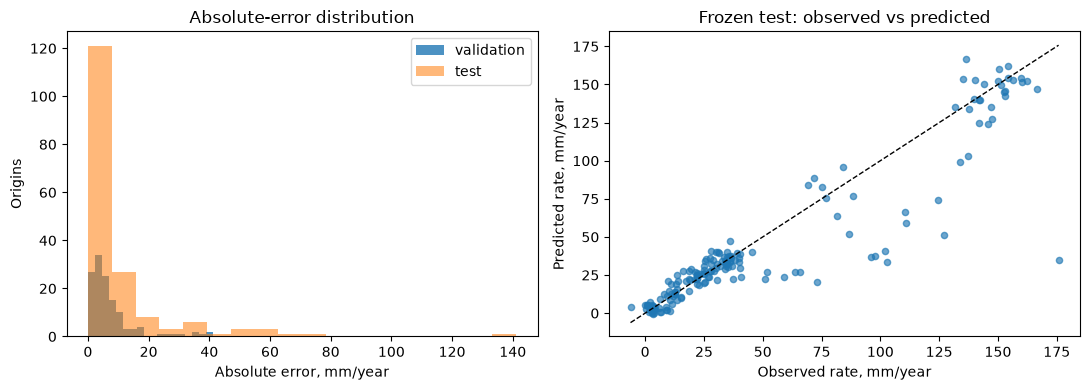

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
validation_errors = development_predictions.loc[
    development_predictions['design'].eq('temporal_holdout')
    & development_predictions['model_id'].eq(candidate['selected_model']),
    'absolute_error',
]
axes[0].hist(validation_errors, bins=18, alpha=0.8, label='validation')
axes[0].hist(test_predictions['absolute_error'], bins=18, alpha=0.55, label='test')
axes[0].set_title('Absolute-error distribution')
axes[0].set_xlabel('Absolute error, mm/year')
axes[0].set_ylabel('Origins')
axes[0].legend()

axes[1].scatter(test_predictions['y_true'], test_predictions['y_pred'], alpha=0.65, s=20)
limits = [min(test_predictions['y_true'].min(), test_predictions['y_pred'].min()),
          max(test_predictions['y_true'].max(), test_predictions['y_pred'].max())]
axes[1].plot(limits, limits, '--', color='black', linewidth=1)
axes[1].set_title('Frozen test: observed vs predicted')
axes[1].set_xlabel('Observed rate, mm/year')
axes[1].set_ylabel('Predicted rate, mm/year')
plt.tight_layout()
plt.show()

### Independent calculation checks

In [10]:
def independent_metrics(frame):
    truth = frame['y_true'].to_numpy(float)
    prediction = frame['y_pred'].to_numpy(float)
    error = prediction - truth
    denominator = np.sum((truth - truth.mean()) ** 2)
    return {
        'mae': np.mean(np.abs(error)),
        'rmse': np.sqrt(np.mean(error ** 2)),
        'bias': np.mean(error),
        'r2': 1.0 - np.sum(error ** 2) / denominator,
    }

recomputed_test = independent_metrics(test_predictions)
for metric, expected in recomputed_test.items():
    assert np.isclose(float(test_row[metric]), expected, rtol=1e-10, atol=1e-10)
assert validation_report['status'] == 'PASS'
assert validation_report['summary']['failed'] == 0
{'recomputed_test': recomputed_test, 'validation_checks': validation_report['summary']}

{'recomputed_test': {'mae': np.float64(10.13476484697878),
  'rmse': np.float64(19.877726895116904),
  'bias': np.float64(-5.164626159041114),
  'r2': np.float64(0.848279382190594)},
 'validation_checks': {'checks': 93, 'failed': 0}}

## Takeaways

1. В Gate B0/B1 простой last-rate baseline оказался устойчивее усложнений: ExtraTrees почти сравнялся на temporal/rolling, но резко деградировал в leave-zone-out; Ridge и фиксированный Kalman не превзошли B1 по составному критерию.
2. Test MAE вырос относительно temporal validation на **38.6%**, а отрицательный bias усилился. Это свидетельство временного сдвига и недостаточности persistence как финальной модели, но не разрешение подстраивать уже замороженный кандидат.
3. Результат пригоден как честная нижняя планка и воспроизводимый benchmark. Оценка анализа — **Share with caveats**.
4. Следующий model-development этап должен оставаться на train/validation: adaptive B6 Kalman, интервальные прогнозы и transition-specific validation. Уже увиденный test нельзя использовать для выбора их параметров; для честного сравнения потребуется заранее утверждённый новый внешний/временной holdout либо иной governance-протокол.